# Checking the report's numbers and the closure effect: `eval.py` demo

This notebook is a runnable walk-through of **`eval.py`**, the entry point of the iteration-3 evaluation artifact `art__i2cIye01VnN`. The evaluation is read-only, CPU-only and costs $0. It audits five iteration-2 artifacts in three parts:

| Part | What it checks | Headline result |
|---|---|---|
| **1. Numbers of record** | 406 numbers quoted in the report, each re-derived (182 from item- or row-level files), with a drift flag against the report | 42 non-OK flags: 14 WRONG_ESTIMATOR, 10 WRONG_UNITS, 9 WRONG_DEFINITION, 8 DRIFT_VALUE, 1 NOT_REDERIVABLE |
| **2. R1a turnover pre-check** | Does the E_up *closure* effect survive once turnover (new-relation rate, novelty, beta_sim, volume, age) is residualised out? | AMBIGUOUS / UNDERPOWERED for main, MeSH and pooled (main S_res -0.566 [-1.14, 0.09], retained 0.75) |
| **3. Decision rules (a)–(d)** | The rules fixed in iteration 2, the 9-row aligned-block IVW/Q table, the held-out seal audit and the coverage table | (a) triggered, (b) pilot-only, (c) not met, (d) sealed |

**What runs here.** In the original pipeline, `eval.py` calls `part1_record.main()`, `part2_r1a.main()` and `part3_rules.main()`. These three scripts read hundreds of iteration-2 files, most of them parquet, that are not available in Colab. This demo therefore loads their **already-computed intermediate outputs** from `mini_demo_data.json`. It then runs:
1. two pieces of the original computation that are cheap enough to recompute: Part 3's `aligned_block()` (IVW/Cochran Q over MeSH vs main) and Part 2's IVW pooling across populations, both through the original `common.ivw` helper;
2. the whole of `eval.py`'s `main()` assembly unchanged (metrics plus the six output datasets);
3. a results and visualisation section that compares the metrics against the values the full run recorded.

`mini_demo_data.json` contains 100 of the 406 record rows (all 42 non-OK flags, every headline id, and a spread of OK and MISSING_IN_REPORT rows). The aggregate counts `record_n_*` come from the full record summary.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')

## Imports

These are the original `eval.py` imports (`json`, `math`, `time`, `numpy`, `loguru`), plus the ones that `common.py` and `part3_rules.py` need (`pandas`, `scipy`). `matplotlib` is added for the final plots. The original `import common as K` is replaced by a small namespace, `K`, that is defined in the helpers cell below.

In [2]:
from __future__ import annotations

import json
import math
import sys
import time
import types

import numpy as np
import pandas as pd
from loguru import logger

import matplotlib.pyplot as plt

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

## Load the demo data (GitHub URL with a local fallback)

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/fork/run_-5obKGrJFD0H/round-3/evaluation-1/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print({k: (len(v) if hasattr(v, "__len__") else v) for k, v in data.items()})
print("record rows in demo:", len(data["record_rows"]), "| R1a event rows:", len(data["r1a"]["event"]),
      "| correlations:", len(data["r1a"]["correlations"]))

{'description': 448, 'record_summary': 5, 'record_rows': 100, 'r1a': 8, 'p3': 5, 'reference_metrics_agg': 117, 'aligned_inputs': 4}
record rows in demo: 100 | R1a event rows: 22 | correlations: 13


## Config

The evaluation is deterministic and runs in seconds, so it has no epochs or iteration counts to tune. The one size knob is the number of numbers-of-record rows fed into the Part 1 dataset: the demo file holds 100 of the 406 rows, and the full run used all 406 (`record_of_numbers.json`). The tolerances are the ones hard-coded in the original scripts.

In [5]:
MAX_RECORD_ROWS = 100      # rows of the numbers-of-record table to use (demo file holds 100; original full run: 406)
IVW_FILE_TOL = 1e-6        # part3_rules.aligned_block: |S_ivw - file| and |Q - file| tolerance for "reproduced"
MIN_N_INTERPRETABLE = 10   # part3_rules.aligned_block: min n_treated and n_eff_window for an interpretable row

## Shared helpers (from `common.py` and the top of `eval.py`)

These are copied verbatim:
- `HEADER` and `ART_IDS` are the constants that label every R1a output.
- `clean()` converts values to JSON-safe types (NaN and inf become `None`, numpy types become Python types).
- `ivw()` does fixed-effect inverse-variance pooling. It returns Cochran's Q, I² and a Q-profile CI for I². Q has very little power at k = 2, which is why the evaluation never reads a non-significant Q as agreement between the populations.
- `num()` and `evals()` come from `eval.py`. They keep only finite numbers so the `eval_*` fields satisfy the output schema.

In [6]:
HEADER = "PRE-CHECK ON ALREADY-SCREENED DATA; NOT CONFIRMATION; E_up promoted post hoc"
ART_IDS = {"exp_1": "art_BdBvbNuNU8E7", "exp_2": "art_yjFB8Spw2w6M", "exp_3": "art_mbFjmo5rbbf8",
           "exp_4": "art_yWUkgWWKyq_h", "dataset_5": "art_eR1Z7fMlOcxs"}


def clean(x):
    """JSON-safe conversion (NaN/inf -> None, numpy -> python)."""
    if isinstance(x, dict):
        return {str(k): clean(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return [clean(v) for v in x]
    if isinstance(x, (np.integer,)):
        return int(x)
    if isinstance(x, (np.floating, float)):
        v = float(x)
        return None if not math.isfinite(v) else v
    if isinstance(x, np.bool_):
        return bool(x)
    if isinstance(x, np.ndarray):
        return clean(x.tolist())
    return x


def dump(obj, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(clean(obj), indent=1, allow_nan=False))


# ------------------------------------------------------------------ meta-analysis helpers
def ivw(y: list[float], se: list[float]) -> dict:
    """Fixed-effect inverse-variance pooling, Cochran Q, I^2 with Q-profile CI (k small => very imprecise)."""
    from scipy import optimize, stats
    y, se = np.asarray(y, float), np.asarray(se, float)
    w = 1 / se ** 2
    mu = float((w * y).sum() / w.sum())
    se_mu = float(1 / math.sqrt(w.sum()))
    Q = float((w * (y - mu) ** 2).sum())
    k = len(y)
    df = k - 1
    pQ = float(stats.chi2.sf(Q, df)) if df > 0 else float("nan")
    I2 = max(0.0, (Q - df) / Q) if Q > 0 else 0.0
    s2 = df * w.sum() / (w.sum() ** 2 - (w ** 2).sum())  # Higgins-Thompson typical within-study variance

    def qgen(t2: float) -> float:
        ww = 1 / (se ** 2 + t2)
        m = (ww * y).sum() / ww.sum()
        return float((ww * (y - m) ** 2).sum())

    def solve(target: float) -> float:
        if qgen(0.0) <= target:
            return 0.0
        hi = 1.0
        while qgen(hi) > target:
            hi *= 10
            if hi > 1e8:
                return float("nan")
        return float(optimize.brentq(lambda t: qgen(t) - target, 0.0, hi))

    t2_lo = solve(stats.chi2.ppf(0.975, df))
    t2_hi = solve(stats.chi2.ppf(0.025, df))
    i2 = lambda t: t / (t + s2) if np.isfinite(t) else float("nan")  # noqa: E731
    return dict(k=k, S_ivw=mu, se_ivw=se_mu, ci=[mu - 1.96 * se_mu, mu + 1.96 * se_mu],
                z=mu / se_mu, p=float(2 * stats.norm.sf(abs(mu / se_mu))), Q=Q, df=df, p_Q=pQ, I2=I2,
                I2_ci_qprofile=[i2(t2_lo), i2(t2_hi)], tau2_ci_qprofile=[t2_lo, t2_hi],
                note="Cochran Q has very low power at k = 2; a non-significant Q is NOT evidence of homogeneity; "
                     "I^2 CI via Q-profile tau^2 bounds mapped with the Higgins-Thompson typical variance.")


# stand-in for `import common as K` (only the names eval.py / aligned_block use)
K = types.SimpleNamespace(HEADER=HEADER, ART_IDS=ART_IDS, ivw=ivw, dump=dump, clean=clean,
                          WS=Path("."), load_json=lambda p: json.loads(Path(p).read_text()))


def num(x) -> float | None:
    try:
        v = float(x)
    except (TypeError, ValueError):
        return None
    return v if math.isfinite(v) else None


def evals(d: dict) -> dict:
    """eval_* fields must be numbers: keep finite numerics only (bools -> 0/1)."""
    out = {}
    for k, v in d.items():
        if isinstance(v, bool):
            out[f"eval_{k}"] = int(v)
        else:
            n = num(v)
            if n is not None:
                out[f"eval_{k}"] = n
    return out

## Part 3 recomputed: the 9-row aligned-block table (`part3_rules.aligned_block`)

For each label (E, E_alt, E_up) × precursor (accretion_shift_rar, closure, P_rar), the effect S is estimated on **MeSH** (held-out population, exp_4) and on the **main** pool (exp_3 event study). The two are pooled with `ivw()` in two ways:
- with the bootstrap SEs (`S_ivw`, `Q`);
- with **SE = CI width / 3.92** (`S_ivw_ciwidth_se`, `Q_ciwidth_se`). This is the method exp_4 used, so it should reproduce the `S_pooled_ivw` / `Q_heterogeneity` values in exp_4's file exactly.

A row is interpretable only if both populations have at least 10 treated concepts and at least 10 effective window observations.

The function body is the original one. The only changes are that its three inputs (the exp_4 side-by-side CSV, the exp_3 event-study summaries and the exp_4 aligned effects CSV) come from `data["aligned_inputs"]` instead of disk, and that the markdown-table writer is dropped.

In [7]:
AI = data["aligned_inputs"]


def aligned_block() -> pd.DataFrame:
    s = pd.DataFrame(AI["side_by_side"])  # was: pd.read_csv(K.E4 / "results/side_by_side_mainpool_vs_mesh.csv")
    s = s[(s.version == "primary") & s.label.isin(["E", "E_alt", "E_up"]) & s.indicator.isin(["accretion_shift_rar", "closure", "P_rar"])]
    al = pd.DataFrame(AI["rq1_effects_mainpool_aligned"]).astype({"se": float})  # was: pd.read_csv(K.E4 / "results/rq1_effects_mainpool_aligned.csv")
    rows = []
    for r in s.itertuples():
        fn = {"E": "summary.json", "E_alt": "summary_E_alt.json", "E_up": "summary_E_up.json"}[r.label]
        mt = [t for t in AI["event_study_tables"][fn] if t["indicator"] == r.indicator and t["version"] == "primary"][0]
        am = al[(al.label == r.label) & (al.indicator == r.indicator) & (al.version == "primary")].iloc[0]
        se_main, se_mesh = mt["se"], float(am.se) if np.isfinite(am.se) else (r.ci_hi_mesh - r.ci_lo_mesh) / 3.92
        iv = K.ivw([r.S_mesh, r.S_main], [se_mesh, se_main])
        ivc = K.ivw([r.S_mesh, r.S_main], [(r.ci_hi_mesh - r.ci_lo_mesh) / 3.92, (r.ci_hi_main - r.ci_lo_main) / 3.92])
        interp = bool(min(r.n_treated_mesh, r.n_treated_main) >= MIN_N_INTERPRETABLE and r.n_eff_window >= MIN_N_INTERPRETABLE)
        rows.append(dict(label=r.label, indicator=r.indicator, S_mesh=r.S_mesh, ci_lo_mesh=r.ci_lo_mesh, ci_hi_mesh=r.ci_hi_mesh,
                         se_mesh=se_mesh, n_treated_mesh=int(r.n_treated_mesh), n_eff_window=int(r.n_eff_window), p_holm_mesh=r.p_holm_mesh,
                         S_main=r.S_main, ci_lo_main=r.ci_lo_main, ci_hi_main=r.ci_hi_main, se_main=se_main, n_treated_main=int(r.n_treated_main),
                         p_holm_main=r.p_holm_main, p_holm_main_eventstudy_file=mt.get("p_holm"), sign_agree=bool(np.sign(r.S_mesh) == np.sign(r.S_main)),
                         S_ivw=iv["S_ivw"], se_ivw=iv["se_ivw"], ivw_ci_lo=iv["ci"][0], ivw_ci_hi=iv["ci"][1], Q=iv["Q"], p_Q=iv["p_Q"], I2=iv["I2"],
                         S_ivw_file=r.S_pooled_ivw, se_ivw_file=r.se_pooled_ivw, Q_file=r.Q_heterogeneity,
                         S_ivw_ciwidth_se=ivc["S_ivw"], se_ivw_ciwidth_se=ivc["se_ivw"], Q_ciwidth_se=ivc["Q"],
                         ivw_agrees_file=bool(abs(ivc["S_ivw"] - r.S_pooled_ivw) < IVW_FILE_TOL and abs(ivc["Q"] - r.Q_heterogeneity) < IVW_FILE_TOL),
                         ivw_bootstrap_se_vs_file_diff=float(iv["S_ivw"] - r.S_pooled_ivw),
                         S_main_agrees_eventstudy=bool(abs(mt["S"] - r.S_main) < 1e-6),
                         interpretable=interp,
                         note="" if interp else f"NOT interpretable: n_treated main {int(r.n_treated_main)} / MeSH {int(r.n_treated_mesh)}, "
                                                f"n_eff_window {int(r.n_eff_window)} (< 10); Q is meaningless here"))
    df = pd.DataFrame(rows)
    return df


aligned = aligned_block()
ref = pd.DataFrame(data["p3"]["aligned"])
print("IVW (CI-width SE) reproduces exp_4 file in", int(aligned.ivw_agrees_file.sum()), "of", len(aligned), "rows;",
      "interpretable rows:", int(aligned.interpretable.sum()))
print("max |S_ivw - recorded S_ivw| vs the full run:", float(np.abs(aligned.S_ivw.values - ref.S_ivw.values).max()))
aligned[["label", "indicator", "S_mesh", "S_main", "n_treated_mesh", "n_treated_main", "S_ivw_ciwidth_se", "Q_ciwidth_se",
         "ivw_agrees_file", "interpretable"]].round(3)

IVW (CI-width SE) reproduces exp_4 file in 9 of 9 rows; interpretable rows: 5
max |S_ivw - recorded S_ivw| vs the full run: 1.1279536332731155e-10


,label,indicator,S_mesh,S_main,n_treated_mesh,n_treated_main,S_ivw_ciwidth_se,Q_ciwidth_se,ivw_agrees_file,interpretable
0,E,accretion_shift_rar,0.044,-0.104,5,3,-0.043,12.681,True,False
1,E,closure,0.487,-0.625,5,3,-0.624,3.970,True,False
2,E,P_rar,-0.026,0.143,5,3,-0.017,2.356,True,False
3,E_alt,accretion_shift_rar,0.049,-0.021,17,10,0.027,3.235,True,False
4,E_alt,closure,0.081,-0.400,17,10,-0.077,1.940,True,True
5,E_alt,P_rar,0.029,-0.044,17,10,0.026,0.732,True,True
6,E_up,accretion_shift_rar,0.043,-0.140,51,21,0.028,11.421,True,True
7,E_up,closure,-0.185,-0.837,51,21,-0.410,6.160,True,True
8,E_up,P_rar,0.017,-0.007,51,21,0.015,0.535,True,True


## Part 2 recomputed: IVW pooling of the R1a event-study results across populations

The R1a pre-check estimates S for the E_up closure effect under several residualisation specs. There are two versions of S:
- `S_raw_cc`: the raw effect on the complete-case matched sets;
- `S_res`: the effect after closure has been residualised on the turnover block.

Specs: **P** is the primary spec (new-relation rate, novelty, beta_sim_raw, volume, age, plus H for main). **R** uses rarefied Baselga. **V0** is volume only. The **D_*** specs drop one term each. **POS**, **POS_ORACLE** and **NEG** are the positive and negative controls.

`retained = S_res / S_raw_cc` is the share of the closure effect that survives residualisation. This cell re-runs the original pooling loop from `part2_r1a.py` (section 2.5) on the stored per-population event rows. The paired-bootstrap retained CI is not recomputed, because its bootstrap replicates are not stored; that value is taken from the full run.

In [8]:
r1a = data["r1a"]
ev = {(r["population"], r["spec"]): r for r in r1a["event"]}

# ---- 2.5 pooling (original loop)
pool = {}
for name in ["P", "R", "V", "V0", "D_new_rel", "D_novelty", "D_beta_sim", "POS", "POS_ORACLE", "NEG"]:
    a, b = ev[("main", name)], ev[("mesh", name)]
    pool[name] = dict(res=K.ivw([a["S_res"], b["S_res"]], [a["S_res_se"], b["S_res_se"]]),
                      raw_cc=K.ivw([a["S_raw_cc"], b["S_raw_cc"]], [a["S_raw_cc_se"], b["S_raw_cc_se"]]),
                      sign_agree_res=bool(np.sign(a["S_res"]) == np.sign(b["S_res"])))
g, g4 = r1a["gate"]["main"], r1a["gate"]["mesh"]
pool["raw_recorded_files"] = K.ivw([g["S_recorded"], g4["S_recorded"]], [g["se_recorded"], g4["se_recorded"]])

for name in ["P", "R", "V0", "NEG", "POS_ORACLE"]:
    p = pool[name]["res"]
    print(f"{name:11s} IVW S_res {p['S_ivw']:+.3f} [{p['ci'][0]:+.3f}, {p['ci'][1]:+.3f}]  Q {p['Q']:.2f} (p {p['p_Q']:.2f})  I2 {p['I2']:.2f}"
          f"   | recorded {r1a['pooling'][name]['res']['S_ivw']:+.3f}")

P           IVW S_res -0.186 [-0.453, +0.081]  Q 1.88 (p 0.17)  I2 0.47   | recorded -0.186
R           IVW S_res -0.855 [-1.240, -0.470]  Q 4.80 (p 0.03)  I2 0.79   | recorded -0.855
V0          IVW S_res -0.292 [-0.529, -0.055]  Q 5.90 (p 0.02)  I2 0.83   | recorded -0.292
NEG         IVW S_res -0.290 [-0.527, -0.053]  Q 5.96 (p 0.01)  I2 0.83   | recorded -0.290
POS_ORACLE  IVW S_res -0.012 [-0.034, +0.009]  Q 0.00 (p 0.96)  I2 0.00   | recorded -0.012


## Assemble the evaluation (`eval.py` `main()`)

This is the body of `eval.py`'s `main()`. The three `partN.main()` calls are replaced by the intermediate outputs loaded above:

| original | this notebook |
|---|---|
| `r1a = part2_r1a.main()` | `data["r1a"]` (R1a results; the aligned pooling above uses the same event rows) |
| `rec_sum = part1_record.main()` | `data["record_summary"]` |
| `rec = K.load_json(... "record_of_numbers.json")["rows"]` | `data["record_rows"][:MAX_RECORD_ROWS]` |
| `p3 = part3_rules.main()` | the **recomputed** `aligned` DataFrame plus the stored rules, audit and coverage |

Everything after that is unchanged: the headline `metrics_agg` dict and the six datasets (`numbers_of_record`, `r1a_results`, `r1a_within_concept_correlations`, `aligned_block`, `decision_rules`, `coverage`).

In [9]:
t0 = time.time()
r1a = data["r1a"]
rec_sum = data["record_summary"]
p3 = dict(aligned=aligned, rules=data["p3"]["rules"], audit=data["p3"]["audit"], coverage=pd.DataFrame(data["p3"]["coverage"]))
rec = data["record_rows"][:MAX_RECORD_ROWS]
byid = {r["id"]: r for r in rec}
ev = {(r["population"], r["spec"]): r for r in r1a["event"]}
corr = {(c["population"], c["pair"]): c for c in r1a["correlations"]}
rules = p3["rules"]
audit = p3["audit"]


def rv(i: str) -> float | None:
    return num(byid[i]["value"]) if i in byid else None


m = dict(record_n_rows=rec_sum["n_rows"], record_n_recomputed=rec_sum["n_recomputed"], record_n_not_rederivable=rec_sum["n_not_rederivable"],
         record_n_flags=rec_sum["n_flags"])
for f, c in rec_sum["n_flags_by_type"].items():
    m[f"record_n_flag_{f}"] = c
m.update(classifier_precision=rv("B1.clf.tF1.precision"), classifier_recall=rv("B1.clf.tF1.recall"), classifier_accuracy=rv("B1.clf.tF1.accuracy"),
         classifier_f1=rv("B1.clf.tF1.f1"), classifier_auc=rv("B1.clf.auc"), classifier_kappa=rv("B1.clf.tF1.kappa"),
         majority_all_positive_f1=rv("B1.base.all_positive_f1"), classifier_f1_minus_all_positive=rv("B1.clf.delta_f1_vs_allpos"),
         classifier_minus_llmA_f1=rv("B1.clf_minus_llmA.f1"), classifier_minus_llmB_f1=rv("B1.clf_minus_llmB.f1"),
         main_E_up_logit_delta_auc=rv("B3.E_up.logit.delta_auc"), main_E_up_hgb_delta_auc=rv("B3.E_up.hgb.delta_auc"))
for pop in ("main", "mesh"):
    r = ev[(pop, "P")]
    m.update({f"{pop}_S_raw": r["S_raw"], f"{pop}_S_raw_cc": r["S_raw_cc"], f"{pop}_S_res": r["S_res"], f"{pop}_S_res_ci_lo": r["S_res_ci"][0],
              f"{pop}_S_res_ci_hi": r["S_res_ci"][1], f"{pop}_S_fit": r["S_fit"], f"{pop}_retained": r["retained"],
              f"{pop}_retained_ci_lo": r["retained_ci"][0], f"{pop}_retained_ci_hi": r["retained_ci"][1], f"{pop}_mde_res_sd": r["mde_res_in_sd"],
              f"{pop}_n_treated_res": r["n_treated_res"], f"{pop}_gate_S_exact": int(r1a["gate"][pop]["S_exact"]),
              f"{pop}_gate_passed": int(r1a["gate"][pop]["passed"]),
              f"{pop}_verdict_not_reducible": int(r1a["verdicts"][pop]["verdict"].startswith("NOT REDUCIBLE")),
              f"{pop}_verdict_largely_turnover": int(r1a["verdicts"][pop]["verdict"].startswith("LARGELY")),
              f"{pop}_retained_volume_only_V0": ev[(pop, "V0")]["retained"], f"{pop}_retained_spec_R_rarefied": ev[(pop, "R")]["retained"],
              f"{pop}_neg_control_retained_vs_V0": r1a["controls"][pop]["NEG"]["retained_vs_V0"],
              f"{pop}_pos_oracle_retained": r1a["controls"][pop]["POS_ORACLE"]["retained"],
              f"{pop}_pos_closure_raw_retained": r1a["controls"][pop]["POS"]["retained"]})
    for key in ("new_rel", "novelty", "beta_sim", "beta_sim_rar"):
        c = corr[(pop, f"closure~{key}")]
        m[f"{pop}_r_within_closure_{key}"] = c.get("r_within")
        m[f"{pop}_r_within_closure_{key}_ci_lo"] = c.get("r_within_ci", [None, None])[0]
        m[f"{pop}_r_within_closure_{key}_ci_hi"] = c.get("r_within_ci", [None, None])[1]
pr = r1a["pooling"]
m.update(ivw_S_res=pr["P"]["res"]["S_ivw"], ivw_se_res=pr["P"]["res"]["se_ivw"], ivw_S_res_ci_lo=pr["P"]["res"]["ci"][0],
         ivw_S_res_ci_hi=pr["P"]["res"]["ci"][1], Q_res=pr["P"]["res"]["Q"], p_Q_res=pr["P"]["res"]["p_Q"], I2_res=pr["P"]["res"]["I2"],
         ivw_S_raw_cc=pr["P"]["raw_cc"]["S_ivw"], Q_raw_cc=pr["P"]["raw_cc"]["Q"], ivw_S_raw_recorded=pr["raw_recorded_files"]["S_ivw"],
         Q_raw_recorded=pr["raw_recorded_files"]["Q"], pooled_retained=pr["pooled_verdict"]["retained"],
         pooled_retained_ci_lo=pr["pooled_verdict"]["retained_ci"][0], pooled_retained_ci_hi=pr["pooled_verdict"]["retained_ci"][1],
         main_placebo_S_res=r1a["controls"]["main"]["PLACEBO"]["S_res"],
         rule_a_triggered=int(rules["a"]["triggered"]), rule_b_pilot_only=int(rules["b"]["pilot_only"]), rule_c_met=int(rules["c"]["met"]),
         rule_d_sealed=int(rules["d"]["sealed"]), heldout_id_hits_exp3_exp4=audit["hits_exp3_exp4_total"],
         heldout_files_scanned=audit["files_scanned_exp3_exp4"], heldout_ids_dataset5=audit["id_sets"]["n_heldout_dataset5"],
         heldout_iter1_subset=int(audit["id_sets"]["iter1_subset_of_dataset5"]),
         aligned_n_interpretable=int(p3["aligned"].interpretable.sum()), aligned_n_file_reproduced=int(p3["aligned"].ivw_agrees_file.sum()),
         coverage_n_done=int((p3["coverage"].status == "done").sum()), coverage_n_partial=int((p3["coverage"].status == "partial").sum()),
         coverage_n_planned=int((p3["coverage"].status == "planned").sum()), runtime_s=time.time() - t0)
metrics = {k: float(v) for k, v in m.items() if num(v) is not None}
print(len(metrics), "metrics")

117 metrics


### Build the six output datasets

Each dataset turns one intermediate table into schema-style examples. Every example has an `input` (the claim or question), an `output` (the value or verdict), `metadata_*` context fields and numeric `eval_*` fields. The logic is unchanged from `eval.py`.

In [10]:
# ---------------- datasets
ds_rec = []
for r in rec:
    ex = {"input": r["claim"], "output": "" if r["value"] is None else f"{r['value']:.6g}",
          "metadata_id": r["id"], "metadata_block": r["block"], "metadata_flag": r["flag"], "metadata_unit": r["unit"],
          "metadata_estimator": r["estimator"], "metadata_source_path": r["source_path"], "metadata_source_key": r["source_key"],
          "metadata_recomputed": r["recomputed"], "metadata_recompute_method": r["recompute_method"], "metadata_note": r["note"],
          "metadata_report_line": r["report_line"], "predict_report_value": "" if r["report_value"] is None else f"{r['report_value']:g}"}
    if r.get("hash_hex"):
        ex["output"] = r["hash_hex"]
        ex["metadata_hash_match"] = r.get("hash_match")
    ex.update(evals(dict(value=r["value"], ci_lo=r["ci_lo"], ci_hi=r["ci_hi"], n=r["n"], report_value=r["report_value"],
                         agrees=r["agrees"] if r["agrees"] is not None else None, flag_ok=r["flag"] in ("OK", "MISSING_IN_REPORT"))))
    ds_rec.append(ex)
ds_r1a = []
for r in r1a["event"]:
    ex = {"input": f"R1a event study E_up closure, population={r['population']}, residualisation spec={r['spec']} ({K.HEADER})",
          "output": r["verdict_rule_applied"], "metadata_population": r["population"], "metadata_spec": r["spec"],
          "metadata_diff_k_raw": r["diff_k_raw"], "metadata_diff_k_res": r["diff_k_res"], "metadata_header": K.HEADER}
    ex.update(evals({k: r[k] for k in ("S_raw", "S_raw_cc", "S_res", "S_res_se", "S_res_p", "S_fit", "retained", "mde_res", "mde_res_in_sd",
                                       "n_treated_raw", "n_treated_res", "treated_lost", "retained_boot_dropped")}))
    ex.update(evals(dict(S_res_ci_lo=r["S_res_ci"][0], S_res_ci_hi=r["S_res_ci"][1], retained_ci_lo=r["retained_ci"][0],
                         retained_ci_hi=r["retained_ci"][1], S_fit_ci_lo=r["S_fit_ci"][0], S_fit_ci_hi=r["S_fit_ci"][1])))
    ds_r1a.append(ex)
ds_corr = []
for c in r1a["correlations"]:
    if "r_within" not in c:
        continue
    ex = {"input": f"Within-concept correlation {c['pair']} ({c['x']} vs {c['y']}), population={c['population']}",
          "output": f"{c['r_within']:.3f} [{c['r_within_ci'][0]:.3f}, {c['r_within_ci'][1]:.3f}]", "metadata_role": c["role"]}
    ex.update(evals(dict(r_within=c["r_within"], r_within_ci_lo=c["r_within_ci"][0], r_within_ci_hi=c["r_within_ci"][1],
                         rho_within=c["rho_within"], r_pooled=c["r_pooled"], n_concepts=c["n_concepts"], n_rows=c["n_rows"])))
    ds_corr.append(ex)
ds_al = []
for r in p3["aligned"].to_dict("records"):
    ex = {"input": f"Aligned block {r['label']} x {r['indicator']}: MeSH vs main S, IVW and Q",
          "output": f"S_mesh {r['S_mesh']:.3f}, S_main {r['S_main']:.3f}, IVW {r['S_ivw_ciwidth_se']:.3f}, Q {r['Q_ciwidth_se']:.2f}, "
                    f"interpretable={r['interpretable']}", "metadata_note": r["note"]}
    ex.update(evals({k: v for k, v in r.items() if k not in ("label", "indicator", "note")}))
    ds_al.append(ex)
ds_rules = []
for k in "abcd":
    rr = rules[k]
    ex = {"input": f"Decision rule ({k}): {rr.get('text') or rr.get('condition')}", "output": rr["verdict"],
          "metadata_text_status": rr["text_status"], "metadata_source": rr["source"]}
    flag = {"a": rr.get("triggered"), "b": rr.get("pilot_only"), "c": rr.get("met"), "d": rr.get("sealed")}[k]
    ex["eval_rule_outcome"] = int(bool(flag))
    if k == "a":
        ex.update(evals(dict(gate_a_share=rr["value"], graft_events_total=rr["graft_events"]["total"], graft_events_kw5=rr["graft_events"]["kw5"])))
    if k == "b":
        ex.update(evals(dict(realised_N_c=rr["realised_N_c"], mde_delta_auc_070=rr["mde_delta_auc_base070"], mde_delta_auc_080=rr["mde_delta_auc_base080"])))
    if k == "c":
        ex["metadata_per_precursor"] = rr["per_precursor"]
        ex.update(evals(dict(n_precursor_rows_all_met=sum(c["all_met"] for c in rr["per_precursor"]))))
    if k == "d":
        ex.update(evals(dict(hits_exp3_exp4=rr["hits_exp3_exp4"], files_scanned=rr["files_scanned"])))
        ex["metadata_exp2_caveat"] = rr["exp2_caveat"]
    ds_rules.append(ex)
ds_cov = []
for r in p3["coverage"].to_dict("records"):
    ds_cov.append({"input": f"Coverage of {r['item']}", "output": r["status"], "metadata_evidence": r["evidence"], "metadata_gap": r["gap"],
                   "metadata_scheduled": r["scheduled"], "eval_status_score": {"done": 1.0, "partial": 0.5, "planned": 0.0}[r["status"]]})
print({n: len(d) for n, d in [("numbers_of_record", ds_rec), ("r1a_results", ds_r1a), ("r1a_within_concept_correlations", ds_corr),
                              ("aligned_block", ds_al), ("decision_rules", ds_rules), ("coverage", ds_cov)]})

{'numbers_of_record': 100, 'r1a_results': 22, 'r1a_within_concept_correlations': 13, 'aligned_block': 9, 'decision_rules': 4, 'coverage': 8}


### Write the output file

The output keeps the original `exp_eval_sol_out` layout. It is written to `demo_eval_out.json` in the working directory. The original wrote `eval_out.json`; the name is changed so the demo does not overwrite the artifact's real output.

In [11]:
out = {
    "metadata": {
        "evaluation_name": "Fix the record and test closure vs turnover (iteration 3, gen_art_evaluation_1)",
        "description": "Part 1 numbers of record with drift flags vs iter_3/gen_strat/current_report.md; Part 2 R1a turnover pre-check on the two "
                       "already-screened populations; Part 3 decision rules (a)-(d), aligned-block table, held-out seal audit, coverage.",
        "header": K.HEADER,
        "inputs": {k: v for k, v in K.ART_IDS.items()},
        "r1a_spec_sha256": r1a["spec_sha256"],
        "r1a_verdicts": {k: v["verdict"] for k, v in r1a["verdicts"].items()},
        "rules": {k: rules[k]["verdict"] for k in "abcd"},
        "record_flag_counts": rec_sum["n_flags_by_type"],
        "notes": ["All paths are relative to the run root.", "Q is underpowered at k = 2; it is not a test of agreement.",
                  "MeSH reproduction gate: S exact, CI off by 0.025 because exp_4's shared RNG stream cannot be replayed (recorded CI lies inside the "
                  "30-seed Monte-Carlo range).", "Deviation D1: MeSH SPEC P uses beta_sim_raw (the column computed with the main-pool code); "
                  "plan-literal beta_sim is sensitivity B_native."],
    },
    "metrics_agg": metrics,
    "datasets": [dict(dataset="numbers_of_record", examples=ds_rec), dict(dataset="r1a_results", examples=ds_r1a),
                 dict(dataset="r1a_within_concept_correlations", examples=ds_corr), dict(dataset="aligned_block", examples=ds_al),
                 dict(dataset="decision_rules", examples=ds_rules), dict(dataset="coverage", examples=ds_cov)],
}
K.dump(out, K.WS / "demo_eval_out.json")
logger.info(f"demo_eval_out.json written: {len(metrics)} metrics, datasets {[len(d['examples']) for d in out['datasets']]}, {time.time() - t0:.2f}s")

03:44:29|INFO   |demo_eval_out.json written: 117 metrics, datasets [100, 22, 13, 9, 4, 8], 0.06s


## Results and visualisation

**1. Headline metrics vs the full run.** The table puts each headline metric next to the value the full pipeline recorded in `eval_out.json`. `runtime_s` is expected to differ. All other metrics should match exactly, since they come from the same intermediates and the same code.

In [12]:
refm = data["reference_metrics_agg"]
key = ["record_n_rows", "record_n_flags", "record_n_flag_WRONG_ESTIMATOR", "record_n_flag_WRONG_UNITS", "record_n_flag_WRONG_DEFINITION",
       "record_n_flag_DRIFT_VALUE", "classifier_precision", "classifier_recall", "classifier_f1", "classifier_auc", "classifier_kappa",
       "majority_all_positive_f1", "main_E_up_logit_delta_auc", "main_S_raw_cc", "main_S_res", "main_S_res_ci_lo", "main_S_res_ci_hi",
       "main_retained", "mesh_S_res", "mesh_retained", "main_retained_volume_only_V0", "main_retained_spec_R_rarefied",
       "main_pos_oracle_retained", "main_neg_control_retained_vs_V0", "main_r_within_closure_new_rel", "ivw_S_res", "Q_res", "I2_res",
       "rule_a_triggered", "rule_b_pilot_only", "rule_c_met", "rule_d_sealed", "heldout_id_hits_exp3_exp4",
       "aligned_n_interpretable", "aligned_n_file_reproduced", "coverage_n_done", "coverage_n_partial", "coverage_n_planned"]
tab = pd.DataFrame([dict(metric=k, notebook=metrics.get(k), full_run=refm.get(k),
                         match=(metrics.get(k) is not None and refm.get(k) is not None and abs(metrics[k] - refm[k]) < 1e-9)) for k in key])
pd.set_option("display.width", 160)
print(tab.round(4).to_string(index=False))
n_match = sum(1 for k in refm if k != "runtime_s" and k in metrics and abs(metrics[k] - refm[k]) < 1e-9)
print(f"\nAll metrics: {n_match} of {len([k for k in refm if k != 'runtime_s'])} match the full run exactly (runtime_s excluded)")
print("\nR1a verdicts:", out["metadata"]["r1a_verdicts"])
print("Rules:", {k: v for k, v in out["metadata"]["rules"].items()})

                         metric  notebook  full_run  match
                  record_n_rows  406.0000  406.0000   True
                 record_n_flags   42.0000   42.0000   True
  record_n_flag_WRONG_ESTIMATOR   14.0000   14.0000   True
      record_n_flag_WRONG_UNITS   10.0000   10.0000   True
 record_n_flag_WRONG_DEFINITION    9.0000    9.0000   True
      record_n_flag_DRIFT_VALUE    8.0000    8.0000   True
           classifier_precision    0.7590    0.7590   True
              classifier_recall    0.8862    0.8862   True
                  classifier_f1    0.8177    0.8177   True
                 classifier_auc    0.8879    0.8879   True
               classifier_kappa    0.5445    0.5445   True
       majority_all_positive_f1    0.7152    0.7152   True
      main_E_up_logit_delta_auc   -0.0104   -0.0104   True
                  main_S_raw_cc   -0.7577   -0.7577   True
                     main_S_res   -0.5655   -0.5655   True
               main_S_res_ci_lo   -1.1399   -1.1399   Tr

**2. Plots.**
- **Left:** drift flags in the numbers of record, excluding OK and MISSING_IN_REPORT.
- **Middle:** the E_up closure effect before residualisation (`S_raw_cc`) and after (`S_res`), with 95% CIs, for each R1a spec on main and on MeSH. `S_res` is close to `S_raw_cc` when turnover explains little of the effect and close to 0 when turnover explains all of it. The oracle positive control should erase the effect, and the noise negative control should leave it intact.
- **Right:** the aligned-block table, MeSH S vs main S for all 9 label × precursor rows. Filled markers are the interpretable rows. Points below and to the right of the origin disagree in sign.

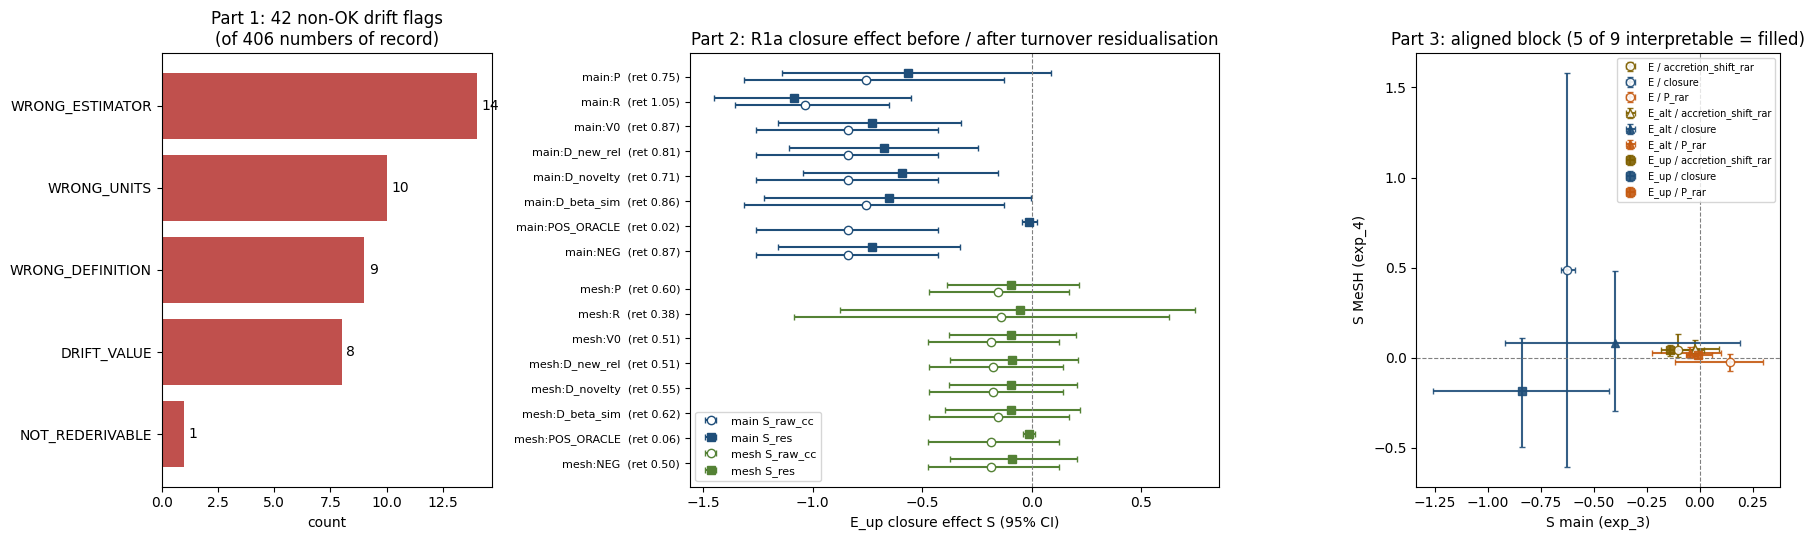

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), gridspec_kw=dict(width_ratios=[1, 1.6, 1.1]))

# (1) drift flags
fl = {k: v for k, v in rec_sum["n_flags_by_type"].items() if k not in ("OK", "MISSING_IN_REPORT") and v > 0}
fl = dict(sorted(fl.items(), key=lambda kv: kv[1]))
axes[0].barh(list(fl), list(fl.values()), color="#c0504d")
for i, v in enumerate(fl.values()):
    axes[0].text(v + 0.2, i, str(v), va="center")
axes[0].set_title(f"Part 1: {rec_sum['n_flags']} non-OK drift flags\n(of {rec_sum['n_rows']} numbers of record)")
axes[0].set_xlabel("count")

# (2) R1a forest: S_raw_cc vs S_res per spec
specs = ["P", "R", "V0", "D_new_rel", "D_novelty", "D_beta_sim", "POS_ORACLE", "NEG"]
ax = axes[1]
ylab, y = [], 0
for pop, col in (("main", "#1f4e79"), ("mesh", "#548235")):
    for s in specs:
        r = ev[(pop, s)]
        ax.errorbar(r["S_raw_cc"], y + 0.15, xerr=[[r["S_raw_cc"] - r["S_raw_cc_ci"][0]], [r["S_raw_cc_ci"][1] - r["S_raw_cc"]]],
                    fmt="o", mfc="white", color=col, capsize=2, label=f"{pop} S_raw_cc" if s == "P" else None)
        ax.errorbar(r["S_res"], y - 0.15, xerr=[[r["S_res"] - r["S_res_ci"][0]], [r["S_res_ci"][1] - r["S_res"]]],
                    fmt="s", color=col, capsize=2, label=f"{pop} S_res" if s == "P" else None)
        ylab.append(f"{pop}:{s}  (ret {r['retained']:.2f})")
        y += 1
    y += 0.5
ax.set_yticks([i if i < len(specs) else i + 0.5 for i in range(len(ylab))], ylab, fontsize=8)
ax.axvline(0, color="grey", lw=0.8, ls="--")
ax.invert_yaxis()
ax.set_xlabel("E_up closure effect S (95% CI)")
ax.set_title("Part 2: R1a closure effect before / after turnover residualisation")
ax.legend(fontsize=8, loc="lower left")

# (3) aligned block
ax = axes[2]
mk = {"E": "o", "E_alt": "^", "E_up": "s"}
cl = {"accretion_shift_rar": "#7f6000", "closure": "#1f4e79", "P_rar": "#c55a11"}
for r in aligned.itertuples():
    ax.errorbar(r.S_main, r.S_mesh, xerr=[[r.S_main - r.ci_lo_main], [r.ci_hi_main - r.S_main]],
                yerr=[[r.S_mesh - r.ci_lo_mesh], [r.ci_hi_mesh - r.S_mesh]], fmt=mk[r.label], color=cl[r.indicator],
                mfc=cl[r.indicator] if r.interpretable else "white", capsize=2, alpha=0.9, label=f"{r.label} / {r.indicator}")
ax.axhline(0, color="grey", lw=0.8, ls="--"); ax.axvline(0, color="grey", lw=0.8, ls="--")
ax.set_xlabel("S main (exp_3)"); ax.set_ylabel("S MeSH (exp_4)")
ax.set_title(f"Part 3: aligned block ({int(aligned.interpretable.sum())} of {len(aligned)} interpretable = filled)")
ax.legend(fontsize=7, loc="best")
plt.tight_layout()
plt.show()